In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [22]:
# Load the dataset
file_path = "C:/Users/misty/OneDrive/Desktop/AirVision AI Delhi/data/cleaned_air_quality_data_delhi.csv"
df = pd.read_csv(file_path)
data = df

In [23]:
# Define the path for the visualizations folder in the project directory
project_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))  # Moves up one level
visualization_dir = os.path.join(project_dir, "visualizations")

# Create the folder if it doesn't exist
if not os.path.exists(visualization_dir):
    os.makedirs(visualization_dir)

print(f"Visualizations will be saved in: {visualization_dir}")

Visualizations will be saved in: C:\Users\misty\OneDrive\Desktop\AirVision AI Delhi\visualizations


In [24]:
# Display basic information
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2553 entries, 0 to 2552
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2553 non-null   object 
 1   pm25    2553 non-null   float64
 2   pm10    2553 non-null   float64
 3   o3      2553 non-null   float64
 4   no2     2553 non-null   float64
 5   so2     2553 non-null   float64
 6   co      2553 non-null   float64
 7   aqi     2553 non-null   float64
dtypes: float64(7), object(1)
memory usage: 159.7+ KB
None
         date   pm25   pm10    o3   no2  so2    co         aqi
0  2025-02-01  325.0  166.0  35.0  24.0  2.0  10.0  374.828829
1  2025-02-02  244.0  136.0  66.0  26.0  3.0  12.0  293.657658
2  2025-02-03  191.0  224.0  32.0  36.0  4.0  14.0  241.135135
3  2025-02-04  223.0  126.0  64.0  20.0  2.0  11.0  272.846847
4  2025-02-05  191.0  130.0  49.0  22.0  5.0  12.0  241.135135


In [25]:
# Check for missing values
print(df.isnull().sum())

date    0
pm25    0
pm10    0
o3      0
no2     0
so2     0
co      0
aqi     0
dtype: int64


In [26]:
# Summary statistics
print(df.describe())

              pm25         pm10           o3          no2          so2  \
count  2553.000000  2553.000000  2553.000000  2553.000000  2553.000000   
mean    187.976107   185.180964    16.901684    18.918136     5.826870   
std      84.966699   121.209918    14.223478    12.730137     4.752638   
min      26.000000    15.000000     1.000000     1.000000     1.000000   
25%     131.000000   101.000000     6.000000    10.000000     2.000000   
50%     165.000000   145.000000    13.000000    16.000000     5.000000   
75%     222.000000   229.000000    24.000000    24.000000     9.000000   
max     828.000000   979.000000   108.000000    98.000000    40.000000   

                co          aqi  
count  2553.000000  2553.000000  
mean     12.712495   247.434924  
std       7.811227    76.461249  
min       1.000000    80.231760  
25%       8.000000   192.564805  
50%      11.000000   218.342342  
75%      16.000000   281.765766  
max      75.000000   500.000000  


## AQI Distribution 

### Purpose:
* This shows the distribution of AQI values in your dataset.
* Helps identify whether the AQI values are normally distributed or skewed.
* Can indicate the most frequent AQI range (e.g., moderate, unhealthy). 

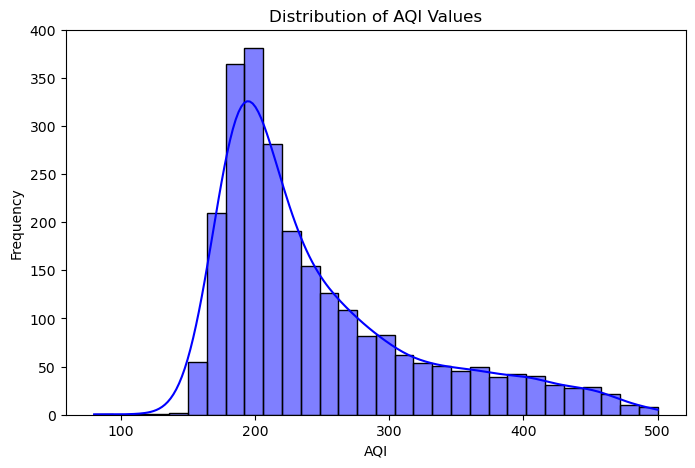

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df['aqi'], bins=30, kde=True, color='blue')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.title('Distribution of AQI Values')

# Save the figure
plt.savefig(os.path.join(visualization_dir, "aqi_distribution.png"))

plt.show()

## AQI Trends Over Time  

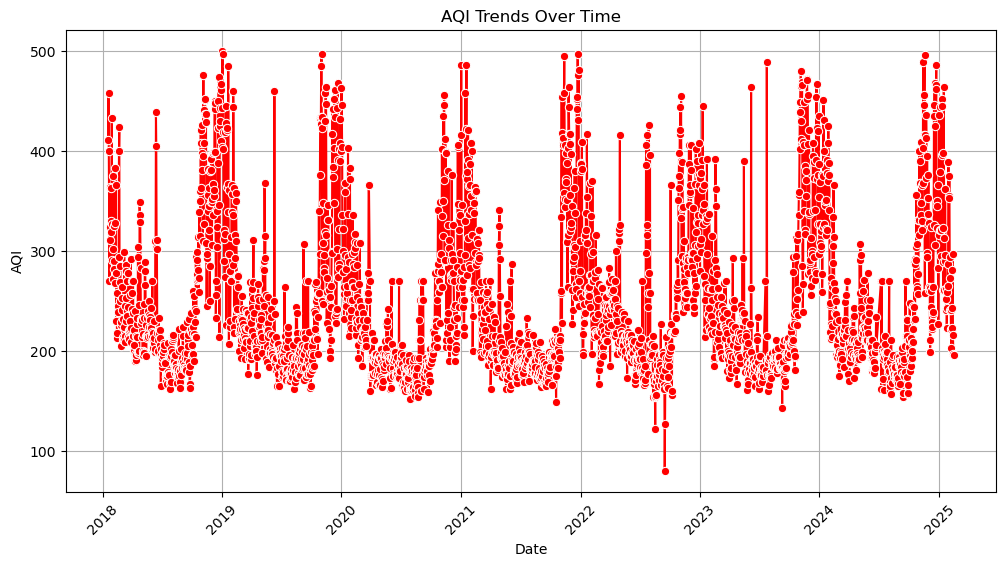

In [28]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='aqi', marker='o', color='red')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('AQI Trends Over Time')
plt.xticks(rotation=45)
plt.grid(True)

# Save the figure
plt.savefig(os.path.join(visualization_dir, "aqi_trends_over_time.png"))

plt.show()

### Using Moving Average (Smoother Trend Line)

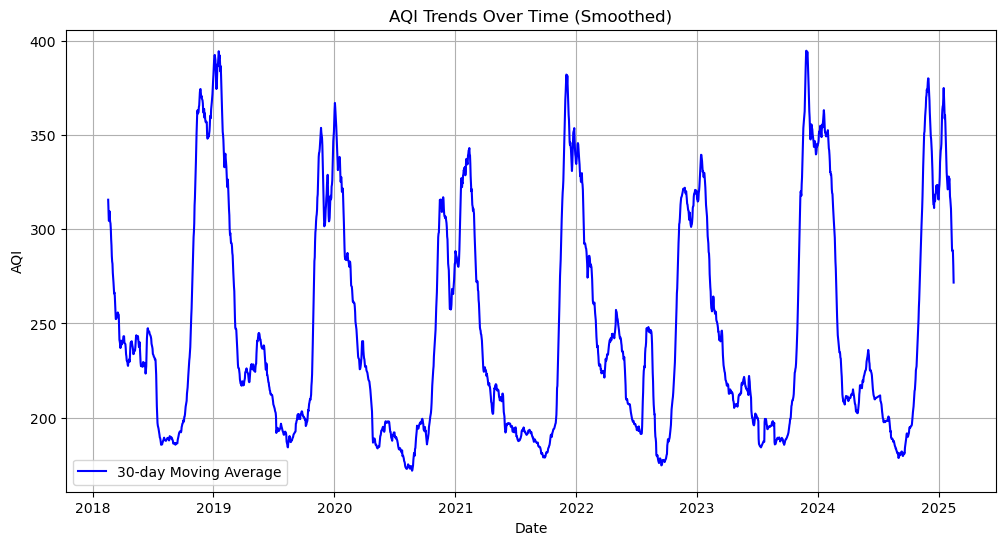

In [29]:
df['date'] = pd.to_datetime(df['date'])  # Ensure 'date' is in datetime format
df.set_index('date', inplace=True)
df['aqi_rolling'] = df['aqi'].rolling(window=30).mean()  # 30-day rolling average

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['aqi_rolling'], color='blue', label='30-day Moving Average')
plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("AQI Trends Over Time (Smoothed)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(visualization_dir, "aqi_trends_smooth.png"))
plt.show()

### Aggregate AQI by Month/Year

Removes clutter, makes seasonal trends more visible.

In [36]:
# plt.figure(figsize=(12, 6))
# plt.plot(df_monthly.index.astype(str), df_monthly, marker='o', linestyle='-', color='green')
# plt.xticks(df_monthly.index[::6].astype(str), rotation=45)  # Show every 6th month
# plt.xlabel("Year-Month")
# plt.ylabel("Average AQI")
# plt.title("Monthly Average AQI Trends Over Time")
# plt.grid(True)
# plt.savefig(os.path.join(visualization_dir, "aqi_trends_monthly.png"))
# plt.show()

### Use a Heatmap for Yearly Trends

Shows seasonal trends across multiple years.

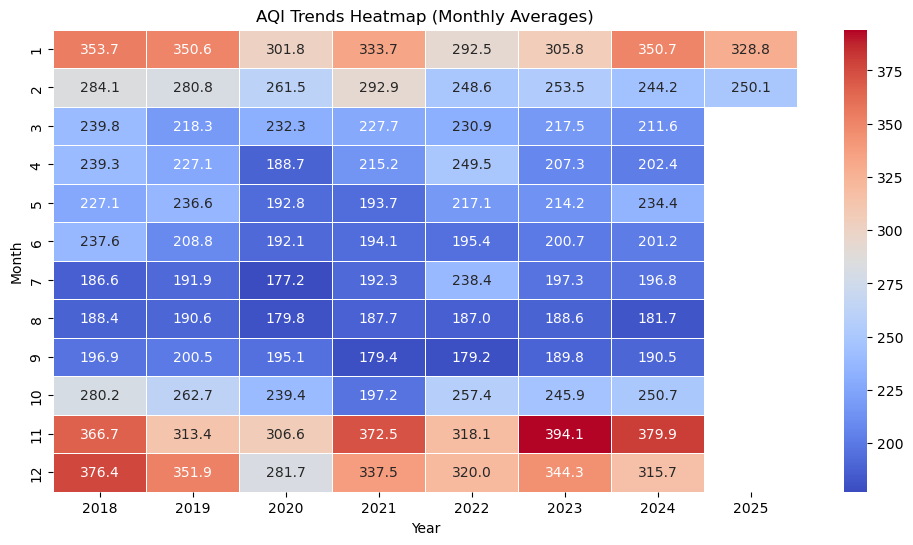

In [31]:
df['year'] = df.index.year
df['month'] = df.index.month
df_pivot = df.pivot_table(index='month', columns='year', values='aqi', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(df_pivot, cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5)
plt.title("AQI Trends Heatmap (Monthly Averages)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.savefig(os.path.join(visualization_dir, "aqi_heatmap.png"))
plt.show()

## Pollutant Correlation Heatmap

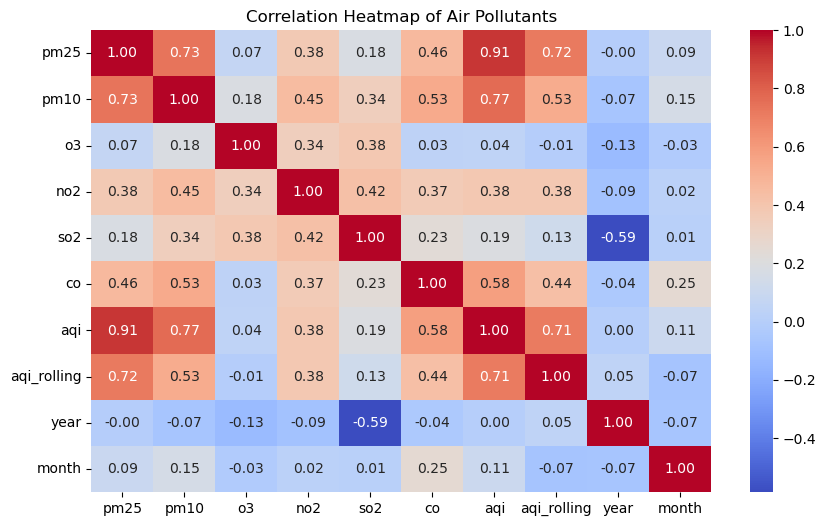

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Air Pollutants')

# Save the figure
plt.savefig(os.path.join(visualization_dir, "pollutant_correlation_heatmap.png"))

plt.show()

## Pollutants vs AQI

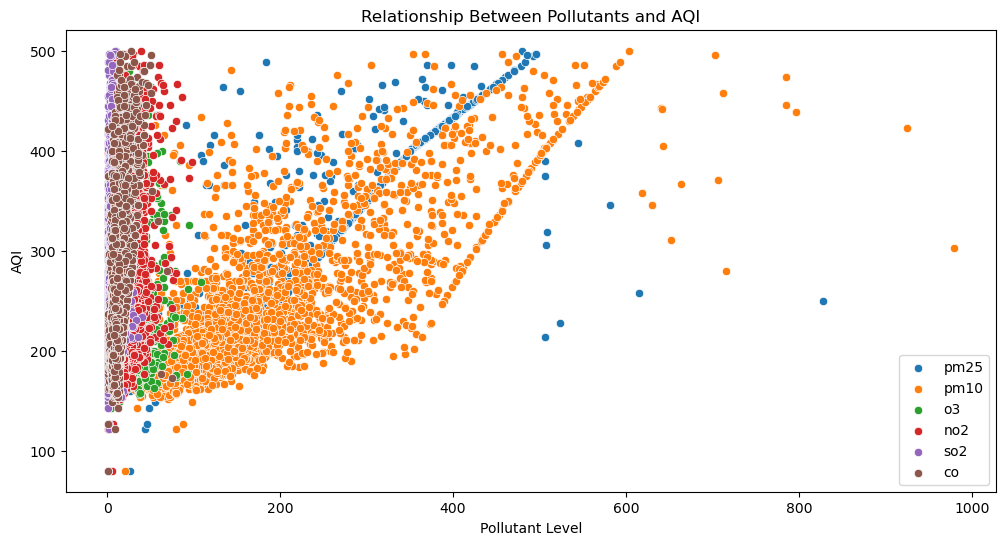

In [33]:
plt.figure(figsize=(12, 6))
pollutants = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']

for pollutant in pollutants:
    sns.scatterplot(data=df, x=pollutant, y='aqi', label=pollutant)

plt.xlabel('Pollutant Level')
plt.ylabel('AQI')
plt.title('Relationship Between Pollutants and AQI')
plt.legend()

# Save the figure
plt.savefig(os.path.join(visualization_dir, "pollutants_vs_aqi.png"))

plt.show()

## Box Plot of AQI for Different Time Periods

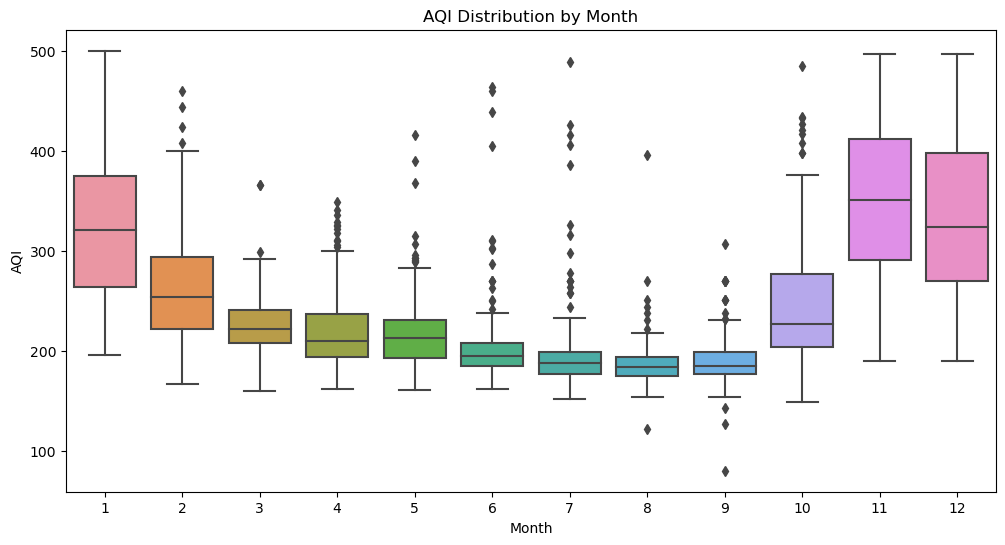

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['month'], y=df['aqi'])
plt.title("AQI Distribution by Month")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.savefig(os.path.join(visualization_dir, "aqi_boxplot_by_month.png"))
plt.show()

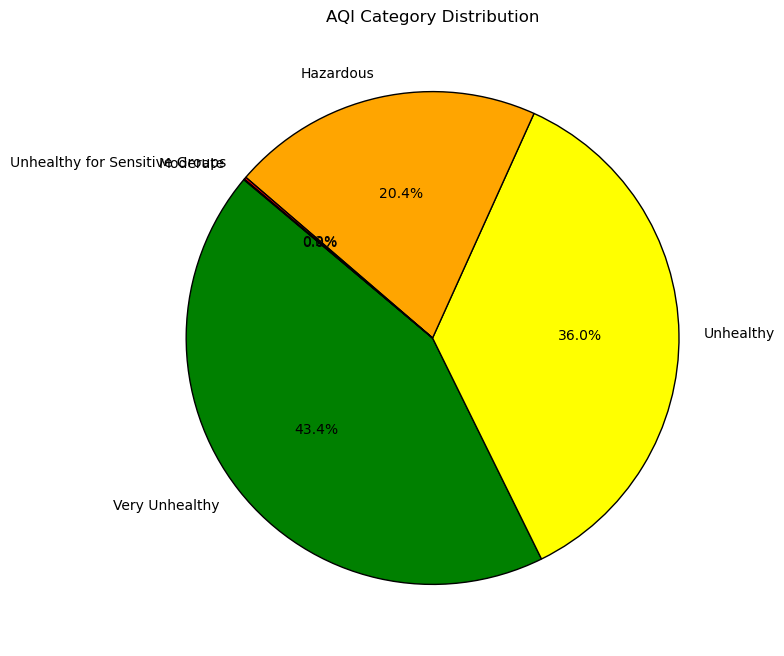

In [35]:
# Define AQI categories
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# Apply the function to categorize AQI values
df['aqi_category'] = df['aqi'].apply(categorize_aqi)

# Count occurrences of each category
aqi_counts = df['aqi_category'].value_counts()

# Define colors for each category
colors = ["green", "yellow", "orange", "red", "purple", "maroon"]

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(aqi_counts, labels=aqi_counts.index, autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title("AQI Category Distribution")
plt.savefig(os.path.join(visualization_dir, "aqi_category_distribution.png"))
plt.show()
